In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "8"

In [2]:
import sys
sys.path.append(os.path.realpath('../../'))

In [3]:
from tqdm.auto import tqdm
from typing import List
import re
from typing import List, Tuple, Dict
from data.dataset import GraphDataset, ReimburseGraphDataset, DataAugmentationLevel, DialogNode, NodeType
import seaborn as sns
import pandas

/mount/arbeitsdaten/asr-2/vaethdk/virtualenvs/cts_en/lib64/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
DEVICE = 'cuda:0'
import torch

In [5]:
human_data_train = ReimburseGraphDataset('en/reimburse/train_graph.json', 'en/reimburse/train_answers.json', False, augmentation=DataAugmentationLevel.NONE, resource_dir="../../resources/")
human_data_test = ReimburseGraphDataset('en/reimburse/test_graph.json', 'en/reimburse/test_answers.json', False, augmentation=DataAugmentationLevel.NONE, resource_dir="../../resources/")
generated_data_train_v1 = ReimburseGraphDataset('en/reimburse/train_graph.json', 'en/reimburse/generated/train_answers.json', False, augmentation=DataAugmentationLevel.ARTIFICIAL_ONLY, augmentation_path="en/reimburse/generated/train_questions_v1.json", resource_dir="../../resources/")
generated_data_train_v2 = ReimburseGraphDataset('en/reimburse/train_graph.json', 'en/reimburse/generated/train_answers.json', False, augmentation=DataAugmentationLevel.ARTIFICIAL_ONLY, augmentation_path="en/reimburse/generated/train_questions_v2.json", resource_dir="../../resources/")
generated_data_train_v3 = ReimburseGraphDataset('en/reimburse/train_graph.json', 'en/reimburse/generated/train_answers.json', False, augmentation=DataAugmentationLevel.ARTIFICIAL_ONLY, augmentation_path="en/reimburse/generated/train_questions_v3.json", resource_dir="../../resources/")

- not using synonyms
===== Dataset Statistics =====
- files:  en/reimburse/train_graph.json en/reimburse/train_answers.json
- synonyms: False
- depth: 20  - degree: 13
- answers: 81
- questions: 279
- loaded original data: True
- loaded generated data: False
- question limit: 0  - maximum loaded:  7
- answer limit: 0  - maximum loaded:  1
- not using synonyms
===== Dataset Statistics =====
- files:  en/reimburse/test_graph.json en/reimburse/test_answers.json
- synonyms: False
- depth: 20  - degree: 13
- answers: 81
- questions: 173
- loaded original data: True
- loaded generated data: False
- question limit: 0  - maximum loaded:  4
- answer limit: 0  - maximum loaded:  1
- Loading questions from  ../../resources/en/reimburse/generated/train_questions_v1.json
- not using synonyms
===== Dataset Statistics =====
- files:  en/reimburse/train_graph.json en/reimburse/generated/train_answers.json
- synonyms: False
- depth: 20  - degree: 13
- answers: 81
- questions: 800
- loaded original data

## Question Lengths

In [9]:
def calculate_question_length(data: GraphDataset):
    question_length = []
    for node in tqdm(data.nodes_by_type[NodeType.INFO]):
        for question in node.questions:
            question_length.append(len(question.text.replace("\n", " ").replace(",", " ").replace(".", " ").replace("!", " ").replace("  ", " ").split(" ")))
    return question_length

In [10]:
question_length_human_train = calculate_question_length(human_data_train)
question_length_human_test = calculate_question_length(human_data_test)
question_length_generated_v1 = calculate_question_length(generated_data_train_v1)
question_length_generated_v2 = calculate_question_length(generated_data_train_v2)
question_length_generated_v3 = calculate_question_length(generated_data_train_v3)

100%|██████████| 80/80 [00:00<00:00, 90200.09it/s]


In [22]:
df = pandas.DataFrame(
    [{"source": "human_questions_train", "#words": length} for length in question_length_human_train] + 
    # [{"source": "human_questions_test", "#words": length} for length in question_length_human_test] +
    [{"source": 'generated v1', "#words": length} for length in question_length_generated_v1] + 
    [{"source": 'generated v2', "#words": length} for length in question_length_generated_v2]
    # [{"source": 'generated v3', "#words": length} for length in question_length_generated_v3] 
)

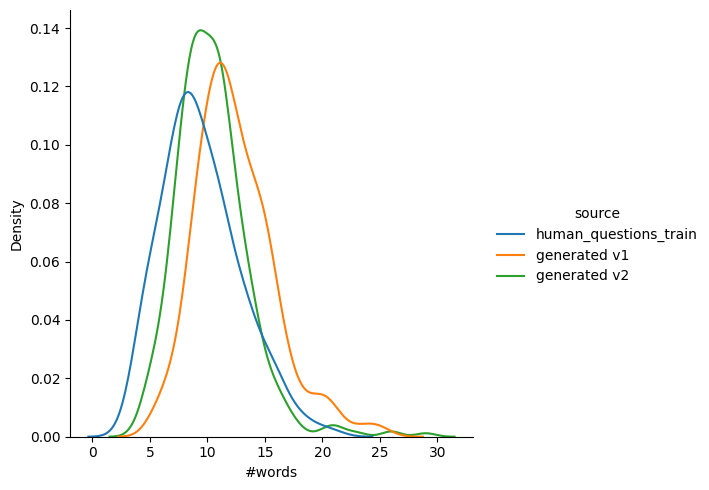

In [9]:
sns.displot(df.reset_index(drop=True), x="#words", kind="kde", hue='source', common_norm=False)

In [23]:
import plotly.express as px


len_human_questions_train = [length for length in question_length_human_train]
len_gen_v1 = [length for length in question_length_generated_v1]
len_gen_v2 = [length for length in question_length_generated_v2]


# fig = px.histogram(df, x="#words", color="source",  histnorm='density', barmode = 'overlay')
# fig.show()

import plotly.figure_factory as ff
colors = ['#D81B60', '#1E88E5', '#004D40']

fig = ff.create_distplot([len_human_questions_train, len_gen_v1, len_gen_v2], ["Human Train", "Gen_V1", "Gen_V2"], 
                        bin_size=1,show_rug=False,show_hist=False,
                        colors=colors)
fig.update_layout(xaxis_title="#Words", yaxis_title="Density",
                plot_bgcolor='rgba(0,0,0,0)',
                font=dict(size=17),
                legend=dict(
                orientation="h",
                yanchor="bottom",
                y=1.02,
                xanchor="center",
                x=0.5
            ))

fig.update_xaxes(showline=True, linewidth=2, linecolor='darkgrey', gridcolor='darkgrey', range=[3,27])
fig.update_yaxes(showline=True, linewidth=2, linecolor='darkgrey', gridcolor='darkgrey')
fig.show()

## Question Similarities

Two scenarios:

1. Pair-wise question similarity between all questions of a node (WITHIN the same dataset)
2. Pair-wise question similarity between the questions of a node from one dataset and the questions from another dataset

In [6]:
from data.dataset import Question
from sentence_transformers import SentenceTransformer, util

similarity_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2', device=DEVICE, cache_folder = '/mount/arbeitsdaten/asr-2/vaethdk/resources/weights').to(DEVICE)

In [7]:
def calculate_similarity(questions_1: List[Question], questions_2: List[Question]):
    #Compute embedding for both lists
    embeddings1 = similarity_model.encode([q.text for q in questions_1], convert_to_tensor=True)
    embeddings2 = similarity_model.encode([q.text for q in questions_2], convert_to_tensor=True)

    #Compute pair-wise cosine-similarities -> #questions_1 x #questions_2
    cosine_scores = util.cos_sim(embeddings1, embeddings2)
    return cosine_scores.to("cpu")


#### 1. scenario: Pair-wise question similarity between all questions of a node (WITHIN the same dataset)

In [8]:
def within_dataset_similarity(dataset: GraphDataset) -> List[float]:
    similarities = []
    for node in tqdm(dataset.nodes_by_type[NodeType.INFO]):
        if len(node.questions) > 0:
            pariwise_sim = calculate_similarity(node.questions, node.questions)
            # ignore self-similarity (matrix diagnoal)
            # also: matrix is symmetric
            # --> only look at triangle above diagonal
            pariwise_sim = torch.triu(pariwise_sim, diagonal=1) # will set elements on and below diagonal to 0
            pariwise_sim = pariwise_sim.view(-1) # convert to list
            relevant_elements = pariwise_sim[pariwise_sim.nonzero()].view(-1) # extract nonzero entries
            similarities.extend(relevant_elements.tolist())     
    return similarities           

In [9]:
human_train_similarity = within_dataset_similarity(human_data_train)
human_test_similarity = within_dataset_similarity(human_data_test)
generated_similarity_v1 = within_dataset_similarity(generated_data_train_v1)
generated_similarity_v2 = within_dataset_similarity(generated_data_train_v2)
generated_similarity_v3 = within_dataset_similarity(generated_data_train_v3)

100%|██████████| 80/80 [00:03<00:00, 21.80it/s]


In [10]:
df = pandas.DataFrame(
    [{"source": "human_questions_train", "similarity": sim} for sim in human_train_similarity] + 
    [{"source": "human_questions_test", "similarity": sim} for sim in human_test_similarity] +
    [{"source": 'generated v1', "similarity": sim} for sim in generated_similarity_v1] + 
    [{"source": 'generated v2', "similarity": sim} for sim in generated_similarity_v2] +
    [{"source": 'generated v3', "similarity": sim} for sim in generated_similarity_v3]
)

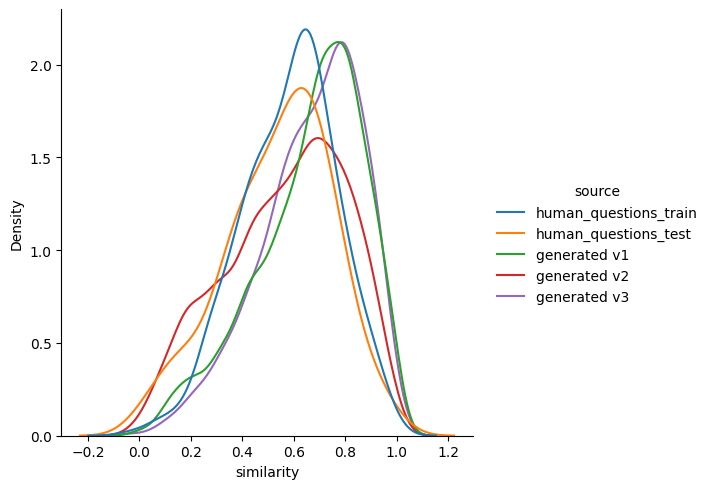

In [11]:
sns.displot(df.reset_index(drop=True), x="similarity", kind="kde", hue='source', common_norm=False)

#### 2. scenario: Pair-wise question similarity between the questions of a node from one dataset and the questions from another dataset

In [12]:
def between_dataset_similarity(dataset_1: GraphDataset, dataset_2: GraphDataset) -> List[float]:
    similarities = []
    for node_1 in tqdm(dataset_1.nodes_by_type[NodeType.INFO]):
        node_2 = dataset_2.nodes_by_key[node_1.key]
        if len(node_1.questions) > 0 and len(node_2.questions) > 0:
            pariwise_sim = calculate_similarity(node_1.questions, node_2.questions)
            pariwise_sim = pariwise_sim.view(-1) # convert to list
            similarities.extend(pariwise_sim.tolist())     
    return similarities           

In [13]:
sim_human_train_vs_human_test = between_dataset_similarity(human_data_train, human_data_test)

sim_human_train_vs_generated_v1 = between_dataset_similarity(human_data_train, generated_data_train_v1)
sim_human_train_vs_generated_v2 = between_dataset_similarity(human_data_train, generated_data_train_v2)
sim_human_train_vs_generated_v3 = between_dataset_similarity(human_data_train, generated_data_train_v3)

sim_human_test_vs_generated_v1 = between_dataset_similarity(human_data_test, generated_data_train_v1)
sim_human_test_vs_generated_v2 = between_dataset_similarity(human_data_test, generated_data_train_v2)
sim_human_test_vs_generated_v3 = between_dataset_similarity(human_data_test, generated_data_train_v3)

100%|██████████| 80/80 [00:03<00:00, 24.85it/s]


In [29]:
from statistics import mean
from scipy import stats


print("Human Train vs. Human Test", mean(sim_human_train_vs_human_test))

print("Human Train vs. Gen V2", mean(sim_human_train_vs_generated_v2))
print("Human Train vs. Gen V3", mean(sim_human_train_vs_generated_v3))

print("Statistical significant improvement in similarity to human data from V2 -> V3")
print(stats.ttest_ind(sim_human_train_vs_generated_v2, sim_human_train_vs_generated_v3))

Human Train vs. Human Test 0.593006776002689
Human Train vs. Gen V2 0.47238727699399174
Human Train vs. Gen V3 0.5170752276577293
Statistical significant improvement in similarity to human data from V2 -> V3
Ttest_indResult(statistic=-6.7387535705033335, pvalue=1.8199060681157317e-11)


In [18]:
df = pandas.DataFrame(
    # [{"source": "human(train) vs human(test)", "similarity": sim} for sim in sim_human_train_vs_human_test] + 
    # [{"source": "human(train) vs generated v1", "similarity": sim} for sim in sim_human_train_vs_generated_v1] +
    [{"source": "human(train) vs generated v2", "similarity": sim} for sim in sim_human_train_vs_generated_v2] +
    [{"source": "human(train) vs generated v3", "similarity": sim} for sim in sim_human_train_vs_generated_v3]
    # [{"source": 'human(test) vs generated v1', "similarity": sim} for sim in sim_human_test_vs_generated_v1] + 
    # [{"source": 'human(test) vs generated v2', "similarity": sim} for sim in sim_human_test_vs_generated_v2] + 
    # [{"source": 'human(test) vs generated v3', "similarity": sim} for sim in sim_human_test_vs_generated_v3] 
)

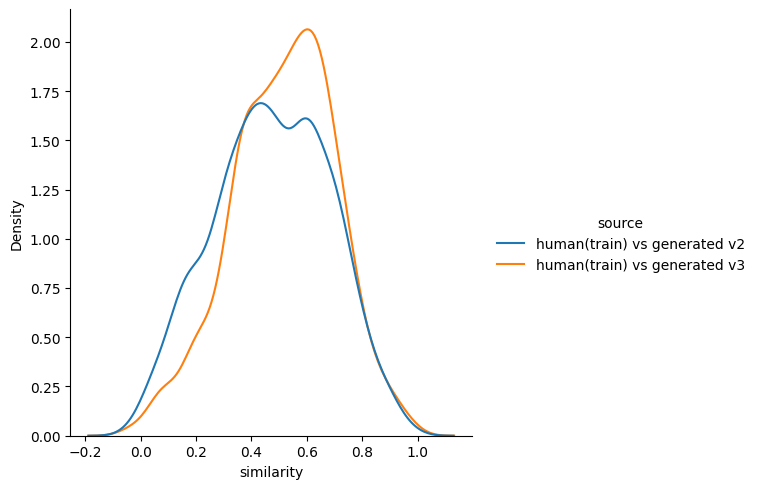

In [19]:
sns.displot(df.reset_index(drop=True), x="similarity", kind="kde", hue='source', common_norm=False)

In [23]:

import plotly.express as px

sim_human_train_vs_generated_v2 = between_dataset_similarity(human_data_train, generated_data_train_v2)
sim_human_train_vs_generated_v3 = between_dataset_similarity(human_data_train, generated_data_train_v3)

# fig = px.histogram(df, x="#words", color="source",  histnorm='density', barmode = 'overlay')
# fig.show()

import plotly.figure_factory as ff
colors = ['#D81B60', '#1E88E5', '#004D40']

fig = ff.create_distplot([sim_human_train_vs_generated_v2, sim_human_train_vs_generated_v3], ["Human Train vs. Gen_V2", "Human Train vs. Gen_V3"], 
                        bin_size=1,show_rug=False,show_hist=False,
                        colors=colors)
fig.update_layout(xaxis_title="Similarity", yaxis_title="Density",
                plot_bgcolor='rgba(0,0,0,0)',
                font=dict(size=17),
                legend=dict(
                orientation="h",
                yanchor="bottom",
                y=1.02,
                xanchor="center",
                x=0.5
            ))

fig.update_xaxes(showline=True, linewidth=2, linecolor='darkgrey', gridcolor='darkgrey', range=[0, 1.0])
fig.update_yaxes(showline=True, linewidth=2, linecolor='darkgrey', gridcolor='darkgrey')
fig.show()

100%|██████████| 80/80 [00:02<00:00, 26.97it/s]


100%|██████████| 80/80 [00:03<00:00, 26.64it/s]


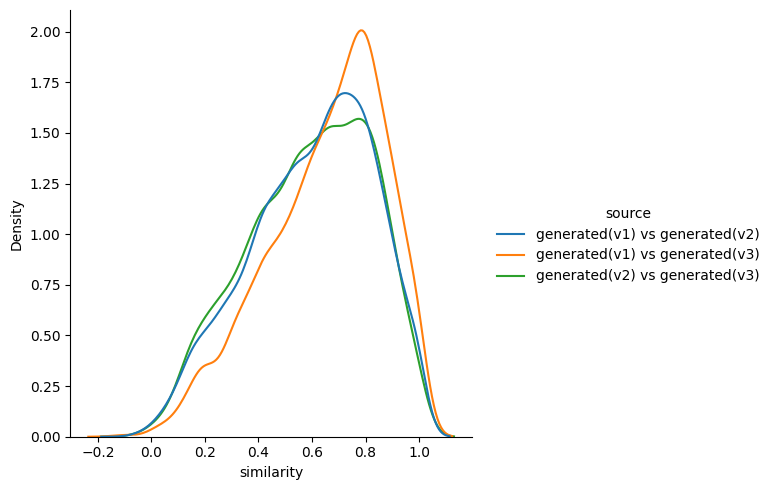

In [20]:
sim_generated_v1_vs_generated_v2 = between_dataset_similarity(generated_data_train_v1, generated_data_train_v2)
sim_generated_v1_vs_generated_v3 = between_dataset_similarity(generated_data_train_v1, generated_data_train_v3)
sim_generated_v2_vs_generated_v3 = between_dataset_similarity(generated_data_train_v2, generated_data_train_v3)

df = pandas.DataFrame(
    [{"source": 'generated(v1) vs generated(v2)', "similarity": sim} for sim in sim_generated_v1_vs_generated_v2] + 
    [{"source": 'generated(v1) vs generated(v3)', "similarity": sim} for sim in sim_generated_v1_vs_generated_v3] +
    [{"source": 'generated(v2) vs generated(v3)', "similarity": sim} for sim in sim_generated_v2_vs_generated_v3]
)

sns.displot(df.reset_index(drop=True), x="similarity", kind="kde", hue='source', common_norm=False)

# Conclusions

1. Generate shorter questions
2. Generate more diverse questions 

# Onboarding


In [20]:
from data.dataset import GraphDataset, StandardGraphDataset

human_data_train = GraphDataset('en/onboarding/train_graph.json', 'en/onboarding/train_answers.json', False, augmentation=DataAugmentationLevel.NONE, resource_dir="../../resources/")
human_data_test = GraphDataset('en/onboarding/test_graph.json', 'en/onboarding/test_answers.json', False, augmentation=DataAugmentationLevel.NONE, resource_dir="../../resources/")
generated_data_train_v1 = StandardGraphDataset('en/onboarding/train_graph.json', 'en/onboarding/generated/train_answers.json', False, augmentation=DataAugmentationLevel.ARTIFICIAL_ONLY, augmentation_path="en/onboarding/generated/train_questions_v1.json", resource_dir="../../resources/")
generated_data_train_v2 = StandardGraphDataset('en/onboarding/train_graph.json', 'en/onboarding/generated/train_answers.json', False, augmentation=DataAugmentationLevel.ARTIFICIAL_ONLY, augmentation_path="en/onboarding/generated/train_questions_v2.json", resource_dir="../../resources/")
generated_data_train_v3 = StandardGraphDataset('en/onboarding/train_graph.json', 'en/onboarding/generated/train_answers.json', False, augmentation=DataAugmentationLevel.ARTIFICIAL_ONLY, augmentation_path="en/onboarding/generated/train_questions_v3.json", resource_dir="../../resources/")

- not using synonyms
===== Dataset Statistics =====
- files:  en/onboarding/train_graph.json en/onboarding/train_answers.json
- synonyms: False
- depth: 12  - degree: 9
- answers: 57
- questions: 141
- loaded original data: True
- loaded generated data: False
- question limit: 0  - maximum loaded:  4
- answer limit: 0  - maximum loaded:  1
- not using synonyms
===== Dataset Statistics =====
- files:  en/onboarding/test_graph.json en/onboarding/test_answers.json
- synonyms: False
- depth: 12  - degree: 9
- answers: 57
- questions: 117
- loaded original data: True
- loaded generated data: False
- question limit: 0  - maximum loaded:  3
- answer limit: 0  - maximum loaded:  1
- Loading questions from  ../../resources/en/onboarding/generated/train_questions_v1.json
- not using synonyms
===== Dataset Statistics =====
- files:  en/onboarding/train_graph.json en/onboarding/generated/train_answers.json
- synonyms: False
- depth: 12  - degree: 9
- answers: 70
- questions: 590
- loaded original 

In [21]:
question_length_human_train = calculate_question_length(human_data_train)
question_length_human_test = calculate_question_length(human_data_test)
question_length_generated_v1 = calculate_question_length(generated_data_train_v1)
question_length_generated_v2 = calculate_question_length(generated_data_train_v2)
question_length_generated_v3 = calculate_question_length(generated_data_train_v3)

100%|██████████| 59/59 [00:00<00:00, 48560.43it/s]


In [ ]:
df = pandas.DataFrame(
    [{"source": "human_questions_train", "#words": length} for length in question_length_human_train] + 
    # [{"source": "human_questions_test", "#words": length} for length in question_length_human_test] +
    [{"source": 'generated v1', "#words": length} for length in question_length_generated_v1] + 
    [{"source": 'generated v2', "#words": length} for length in question_length_generated_v2]
    # [{"source": 'generated v3', "#words": length} for length in question_length_generated_v3] 
)

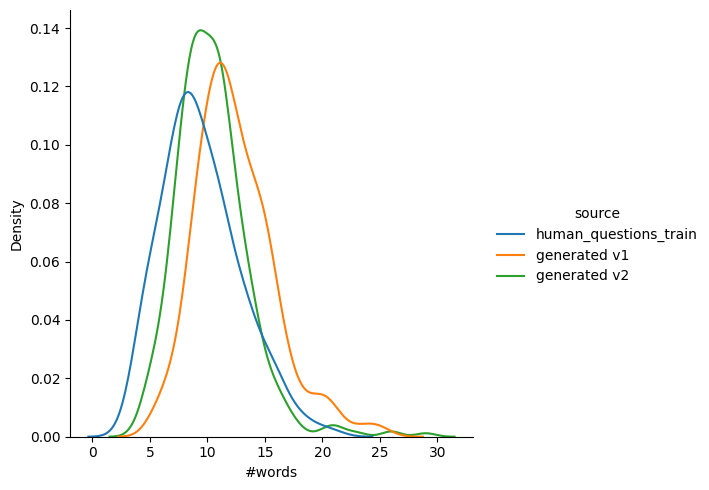

In [22]:
sns.displot(df.reset_index(drop=True), x="#words", kind="kde", hue='source', common_norm=False)

In [2]:
from statistics import mean
from scipy import stats


diagnose_human_success = [1] * int(0.7631 * 500)
diagnose_human_failure = [0] * (500 - int(0.7631 * 500))
diagnose_llama_successes = [1] * int(0.7108 * 500)
diagnose_llama_failure = [0] * (500 - int(0.7108 * 500))
diagnose_chatgpt_successes = [1] * int(0.8512 * 500)
diagnose_chatgpt_failure = [0] * (500 - int(0.8512 * 500))

onboard_human_success = [1] * int(0.7361 * 500)
onboard_human_failure = [0] * (500 - int(0.7361 * 500))
onboard_llama_success = [1] * int(0.6338 * 500)
onboard_llama_failure = [0] * (500 - int(0.5976 * 500))
onboard_chatgpt_success = [1] * int(0.6798 * 500)
onboard_chatgpt_failure = [0] * (500 - int(0.6798 * 500))

# reimburse_human_success = [1] * int(0.7386 * 500)
# reimburse_human_failure = [0] * (500 - int(0.7386 * 500))
# reimburse_llama_success = [1] * int(0.6944 * 500)
# reimburse_llama_failure = [0] * (500 - int(0.6944 * 500))


# print("REIMBURSE: Human Train vs. LLAMA", stats.ttest_ind(reimburse_human_success + reimburse_human_failure, reimburse_llama_success + reimburse_llama_failure))
print("DIAGNOSE: Human Train vs. LLAMA", stats.ttest_ind(diagnose_human_success + diagnose_human_failure, diagnose_llama_successes + diagnose_llama_failure))
print("DIAGNOSE: Human Train vs. ChatGPT", stats.ttest_ind(diagnose_human_success + diagnose_human_failure, diagnose_chatgpt_successes + diagnose_chatgpt_failure))
print("ONBOARD: Human Train vs. LLAMA", stats.ttest_ind(onboard_human_success + onboard_human_failure, onboard_llama_success + onboard_llama_failure))
print("ONBOARD: Human Train vs. ChatGPT", stats.ttest_ind(onboard_human_success + onboard_human_failure, onboard_chatgpt_success + onboard_chatgpt_failure))


DIAGNOSE: Human Train vs. LLAMA Ttest_indResult(statistic=1.866614085966704, pvalue=0.06224857847459957)
DIAGNOSE: Human Train vs. ChatGPT Ttest_indResult(statistic=-3.537161779747852, pvalue=0.000423054285071883)
ONBOARD: Human Train vs. LLAMA Ttest_indResult(statistic=4.313942973630183, pvalue=1.760154949075231e-05)
ONBOARD: Human Train vs. ChatGPT Ttest_indResult(statistic=2.0169871390018175, pvalue=0.04396423424896004)
